Loaded 394 samples and model classes: ['junior', 'manager', 'other']
✅ Saved metrics to reports/eval_metrics_full.json
✅ Saved confusion matrix to reports/confusion_matrix.png
✅ Saved 6 mistake examples to reports/mistakes_examples.csv

🔍 Quick classification report (test set):
              precision    recall  f1-score   support

      junior     0.8333    0.9091    0.8696        11
     manager     0.7692    1.0000    0.8696        10
       other     0.9688    0.8611    0.9118        36

    accuracy                         0.8947        57
   macro avg     0.8571    0.9234    0.8836        57
weighted avg     0.9076    0.8947    0.8962        57



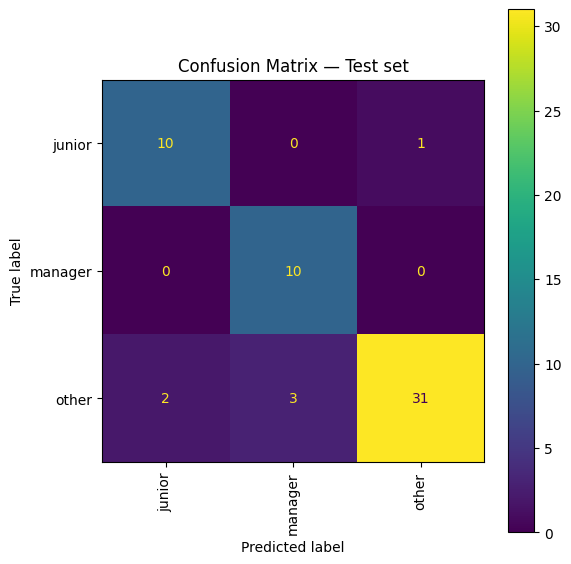

In [1]:
# eval_on_test.py
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

# --- Paths (adjust if needed) ---
FEATURES_PATH = Path("data/features.csv")
MODEL_PATH = Path("models/role_classifier.pkl")
LABEL_ENCODER_PATH = Path("models/label_encoder.pkl")
TFIDF_PATH = Path("models/tfidf_vectorizer.joblib")
SVD_PATH = Path("models/tfidf_svd.joblib")

REPORT_DIR = Path("reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_JSON = REPORT_DIR / "eval_metrics_full.json"
CONFUSION_PNG = REPORT_DIR / "confusion_matrix.png"
MISTAKES_CSV = REPORT_DIR / "mistakes_examples.csv"

# --- Load artifacts ---
assert FEATURES_PATH.exists(), f"Features not found: {FEATURES_PATH}"
assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}"
assert LABEL_ENCODER_PATH.exists(), f"Label encoder not found: {LABEL_ENCODER_PATH}"

df = pd.read_csv(FEATURES_PATH)
model = joblib.load(MODEL_PATH)
le = joblib.load(LABEL_ENCODER_PATH)

print(f"Loaded {len(df)} samples and model classes: {le.classes_.tolist()}")

# --- Recreate same meeting-level split used during training ---
np.random.seed(42)
meetings = df["meeting_id"].unique()
np.random.shuffle(meetings)

n_meetings = len(meetings)
n_train = int(0.7 * n_meetings)
n_val = int(0.15 * n_meetings)
n_train = max(1, n_train)
n_val = max(n_val, 1) if n_meetings - n_train >= 2 else 0

train_meetings = meetings[:n_train]
val_meetings = meetings[n_train:n_train + n_val]
test_meetings = meetings[n_train + n_val:]

test_df = df[df["meeting_id"].isin(test_meetings)].copy()
if test_df.empty:
    raise RuntimeError("Test split is empty. Check meeting split logic or training split used.")

FEATURE_COLS = [c for c in df.columns if c not in ["meeting_id", "speaker_id", "role"]]

X_test = test_df[FEATURE_COLS].apply(pd.to_numeric, errors="coerce").fillna(0.0)
y_test = test_df["role"].astype(str).values

# --- Predict ---
y_pred_enc = model.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)

# --- Metrics ---
report = classification_report(y_test, y_pred, output_dict=True)
macro = f1_score(y_test, y_pred, average="macro")

metrics = {
    "classification_report": report,
    "macro_f1": float(macro),
    "n_test_samples": int(len(test_df)),
    "n_meetings_test": int(len(test_meetings)),
    "classes": le.classes_.tolist()
}

# Save metrics JSON
with open(METRICS_JSON, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"✅ Saved metrics to {METRICS_JSON}")

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, xticks_rotation="vertical", cmap="viridis")
plt.title("Confusion Matrix — Test set")
plt.tight_layout()
fig.savefig(CONFUSION_PNG, dpi=150)
print(f"✅ Saved confusion matrix to {CONFUSION_PNG}")

# Mistake examples (merge original text if available)
# Try to load original labeled_roles.csv (has full_text)
RAW_PATH = Path("data/labeled_roles.csv")
if RAW_PATH.exists():
    raw = pd.read_csv(RAW_PATH)
    keyed = raw.set_index(["meeting_id","speaker_id"])
    # prepare test_key
    test_key = test_df.set_index(["meeting_id","speaker_id"])
    joined = test_key.join(keyed[["full_text"]], how="left")
    joined = joined.reset_index()
else:
    # if not available, just include features
    joined = test_df.reset_index()

joined["y_true"] = y_test
joined["y_pred"] = y_pred
mistakes = joined[joined["y_true"] != joined["y_pred"]]
mistakes.to_csv(MISTAKES_CSV, index=False)
print(f"✅ Saved {len(mistakes)} mistake examples to {MISTAKES_CSV}")

print("\n🔍 Quick classification report (test set):")
print(classification_report(y_test, y_pred, digits=4))


In [2]:
# inference.py
import re
import json
import time
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
from textblob import TextBlob

# Paths
TFIDF_PATH = Path("models/tfidf_vectorizer.joblib")
SVD_PATH = Path("models/tfidf_svd.joblib")
MODEL_PATH = Path("models/role_classifier.pkl")
LABEL_ENCODER_PATH = Path("models/label_encoder.pkl")
LLM_CACHE_PATH = Path("cache/llm_manager_prob_cache.json")

# Load artifacts
tfidf = joblib.load(TFIDF_PATH) if TFIDF_PATH.exists() else None
svd = joblib.load(SVD_PATH) if SVD_PATH.exists() else None
model = joblib.load(MODEL_PATH)
le = joblib.load(LABEL_ENCODER_PATH)

# Heaps of regexes lifted from feature pipeline
HARD_DIRECTIVE_PATTERNS = [
    r"\byou should\b", r"\byou need to\b", r"\bneed to\b",
    r"\bhave to\b", r"\bmake sure\b", r"\bdeadline\b", r"\bblocker\b",
    r"\bassign\b", r"\breview\b.*\bPR\b", r"\bensure\b", r"\bby EOD\b", r"\bI expect\b"
]
SOFT_HELP_PATTERNS = [
    r"\bi['’]?ll help\b", r"\bi will help\b", r"\bi['’]?ll pair\b",
    r"\bpair with you\b", r"\bdm me\b", r"\bmessage me\b", r"\bi can help\b",
    r"\bi can pair\b", r"\bwe can go through\b", r"\bi can walk you through\b"
]
UNCERTAINTY_PATTERNS = [
    r"\bnot sure\b", r"\bstuck\b", r"\bconfused\b", r"\btrying to\b",
    r"\bi think\b", r"\bmaybe\b", r"\bkind of\b", r"\bsort of\b",
    r"\bdon't know\b", r"\bcan't figure\b", r"\bstruggling\b"
]
greeting_re = re.compile(r"^(hi|hey|hello|morning|good morning|good afternoon|good evening)[\s!.,]*$", re.IGNORECASE)

hard_re = re.compile("|".join(HARD_DIRECTIVE_PATTERNS), re.IGNORECASE)
soft_re = re.compile("|".join(SOFT_HELP_PATTERNS), re.IGNORECASE)
uncertainty_re = re.compile("|".join(UNCERTAINTY_PATTERNS), re.IGNORECASE)
you_re = re.compile(r"\byou\b|\byour\b", re.IGNORECASE)
we_re = re.compile(r"\bwe\b|\bles\b|\blet's\b", re.IGNORECASE)
i_re = re.compile(r"\bi\b", re.IGNORECASE)

# Optional LLM scoring helper (uses cached results only, no external call)
def get_cached_llm_score(text: str, cache_path=LLM_CACHE_PATH, default=0.5):
    if not cache_path.exists():
        return default
    try:
        cache = json.load(open(cache_path, "r"))
        return float(cache.get(text, default))
    except Exception:
        return default

# Feature builder (single text)
def build_features_for_text(text: str, meeting_context=None, use_llm=False):
    # light normalization
    s = (text or "").replace("\n", " ").strip()
    s_clean = re.sub(r"\s+", " ", s)

    word_count = len(s_clean.split())
    sentence_count = len(re.findall(r"[.!?]+", s_clean))
    avg_sentence_len = (word_count / sentence_count) if sentence_count > 0 else 0.0
    question_count = len(re.findall(r"\?", s_clean))
    hard_directive_count = len(hard_re.findall(s_clean))
    soft_help_count = len(soft_re.findall(s_clean))
    directive_count = hard_directive_count + soft_help_count
    uncertainty_count = len(uncertainty_re.findall(s_clean))
    sentiment_score = TextBlob(s_clean).sentiment.polarity if s_clean else 0.0
    is_greeting_only = 1 if greeting_re.match(s_clean) else 0

    # pronoun counts
    you_count = len(you_re.findall(s_clean))
    we_count = len(we_re.findall(s_clean))
    i_count = len(i_re.findall(s_clean))
    pronoun_ratio = (you_count + 1) / (i_count + 1)

    # For meeting-relative features we cannot compute without meeting data.
    # We'll set relative fields to 0.5 as neutral unless meeting_context is provided.
    word_count_rel = 0.5
    directive_count_rel = 0.5
    word_count_share = 0.0

    # tfidf + svd transform (if available)
    tfidf_feats = []
    if tfidf is not None and svd is not None:
        vec = tfidf.transform([s_clean])
        sv = svd.transform(vec)
        tfidf_feats = sv.flatten().tolist()
    else:
        # pad with zeros for expected dimensionality if needed
        tfidf_feats = []

    # LLM feature (cached)
    lm_manager_prob = get_cached_llm_score(s_clean) if use_llm else 0.5

    # Compose feature vector in the same order as training FEATURE_COLS
    base = {
        "word_count": word_count,
        "avg_sentence_len": avg_sentence_len,
        "question_count": question_count,
        "hard_directive_count": hard_directive_count,
        "soft_help_count": soft_help_count,
        "directive_count": directive_count,
        "uncertainty_count": uncertainty_count,
        "is_greeting_only": is_greeting_only,
        "sentiment_score": sentiment_score,
        "lm_manager_prob": lm_manager_prob,
        "word_count_rel": word_count_rel,
        "directive_count_rel": directive_count_rel,
        "word_count_share": word_count_share,
        "avg_sentence_len": avg_sentence_len
    }

    feature_vector = list(base.values()) + tfidf_feats
    return feature_vector, base, tfidf_feats

# Predict single utterance
def predict_text(text: str, use_llm=False):
    feat_vec, base, tfidf_feats = build_features_for_text(text, use_llm=use_llm)
    # Build DataFrame with correct shape: feature names must match training FEATURE_COLS order.
    # We'll approximate by reading training feature header if available.
    # Try to load training features header:
    try:
        train_header = list(pd.read_csv("data/features.csv", nrows=0).columns)
        feature_cols = [c for c in train_header if c not in ["meeting_id","speaker_id","role"]]
        # Create df
        row = pd.DataFrame([feat_vec], columns=feature_cols)
    except Exception:
        # fallback: create numeric array and predict directly if dims match
        row = np.array(feat_vec).reshape(1, -1)

    probs = model.predict_proba(row)
    pred_idx = int(np.argmax(probs, axis=1)[0])
    label = le.inverse_transform([pred_idx])[0]
    return {"label": label, "prob": float(probs[0, pred_idx]), "probs": probs.tolist(), "features": base}

# CLI test
if __name__ == "__main__":
    examples = [
        "I’ll pair with you after stand-up — ping me if stuck.",
        "I’m blocked by the CI failing on the build, need help.",
        "Please make sure the release branch is updated by EOD."
    ]
    for ex in examples:
        out = predict_text(ex, use_llm=False)
        print("TEXT:", ex)
        print("PRED:", out["label"], f"(p={out['prob']:.3f})")
        print("FEATURES:", out["features"])
        print("-" * 60)


TEXT: I’ll pair with you after stand-up — ping me if stuck.
PRED: other (p=0.804)
FEATURES: {'word_count': 11, 'avg_sentence_len': 11.0, 'question_count': 0, 'hard_directive_count': 0, 'soft_help_count': 1, 'directive_count': 1, 'uncertainty_count': 1, 'is_greeting_only': 0, 'sentiment_score': 0.0, 'lm_manager_prob': 0.5, 'word_count_rel': 0.5, 'directive_count_rel': 0.5, 'word_count_share': 0.0}
------------------------------------------------------------
TEXT: I’m blocked by the CI failing on the build, need help.
PRED: other (p=0.998)
FEATURES: {'word_count': 11, 'avg_sentence_len': 11.0, 'question_count': 0, 'hard_directive_count': 0, 'soft_help_count': 0, 'directive_count': 0, 'uncertainty_count': 0, 'is_greeting_only': 0, 'sentiment_score': 0.0, 'lm_manager_prob': 0.5, 'word_count_rel': 0.5, 'directive_count_rel': 0.5, 'word_count_share': 0.0}
------------------------------------------------------------
TEXT: Please make sure the release branch is updated by EOD.
PRED: other (p=0